In [1]:
from dataset_loaders import build_data_loaders
from utils.checkpoints import load_ae_from_path
from pathlib import Path
import torch

from utils.config import DatasetConfig
from visualisation import show

In [2]:
ae_path = Path("../checkpoints/autoencoder/flowers.pt")
ae = load_ae_from_path(ae_path)


In [3]:
dataset_cfg = DatasetConfig(
    name="flowers102",
    channels=3,
    height=128,
    width=128,
    num_classes=102,
    num_workers=1
)

dataloader, test_loader = build_data_loaders(dataset_cfg, batch_size=64)


In [4]:
images, labels = next(iter(dataloader))

with torch.no_grad():
    recon, mu, logvar = ae(images)


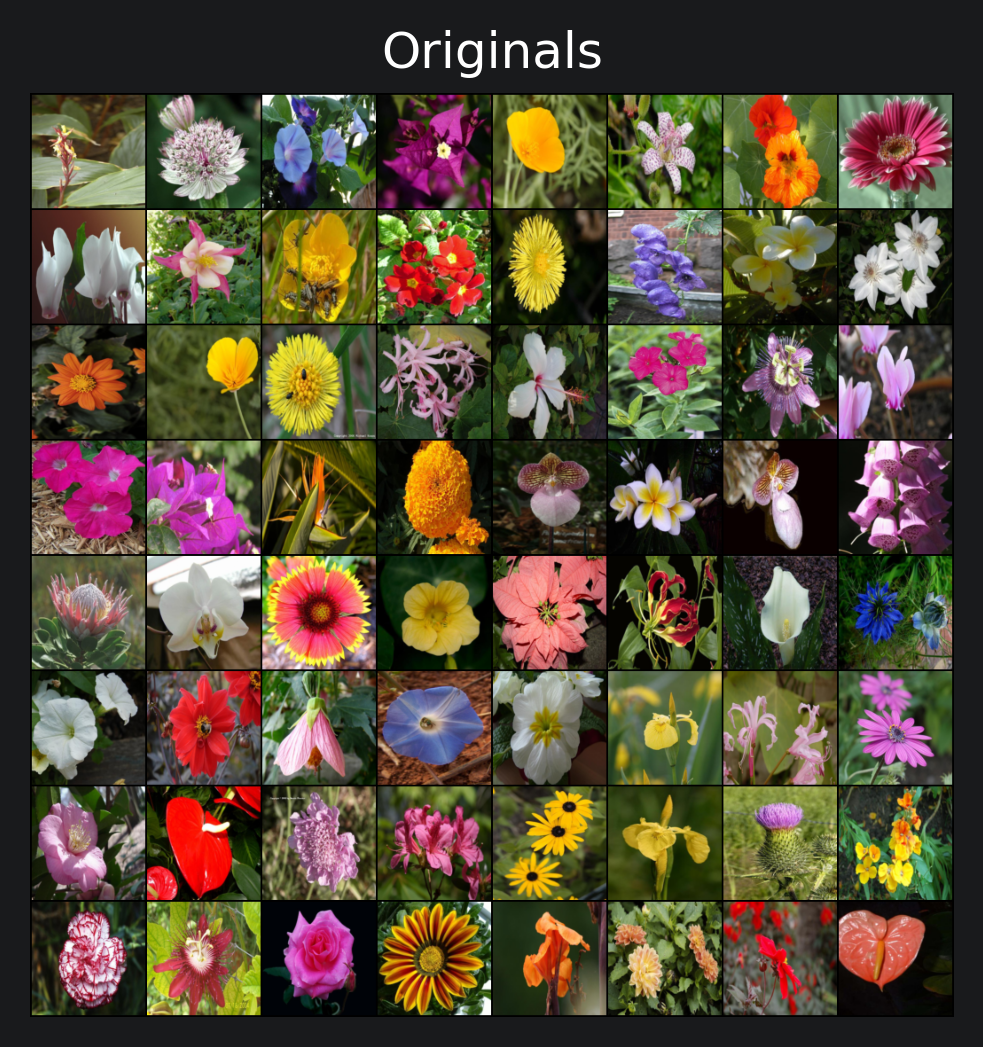

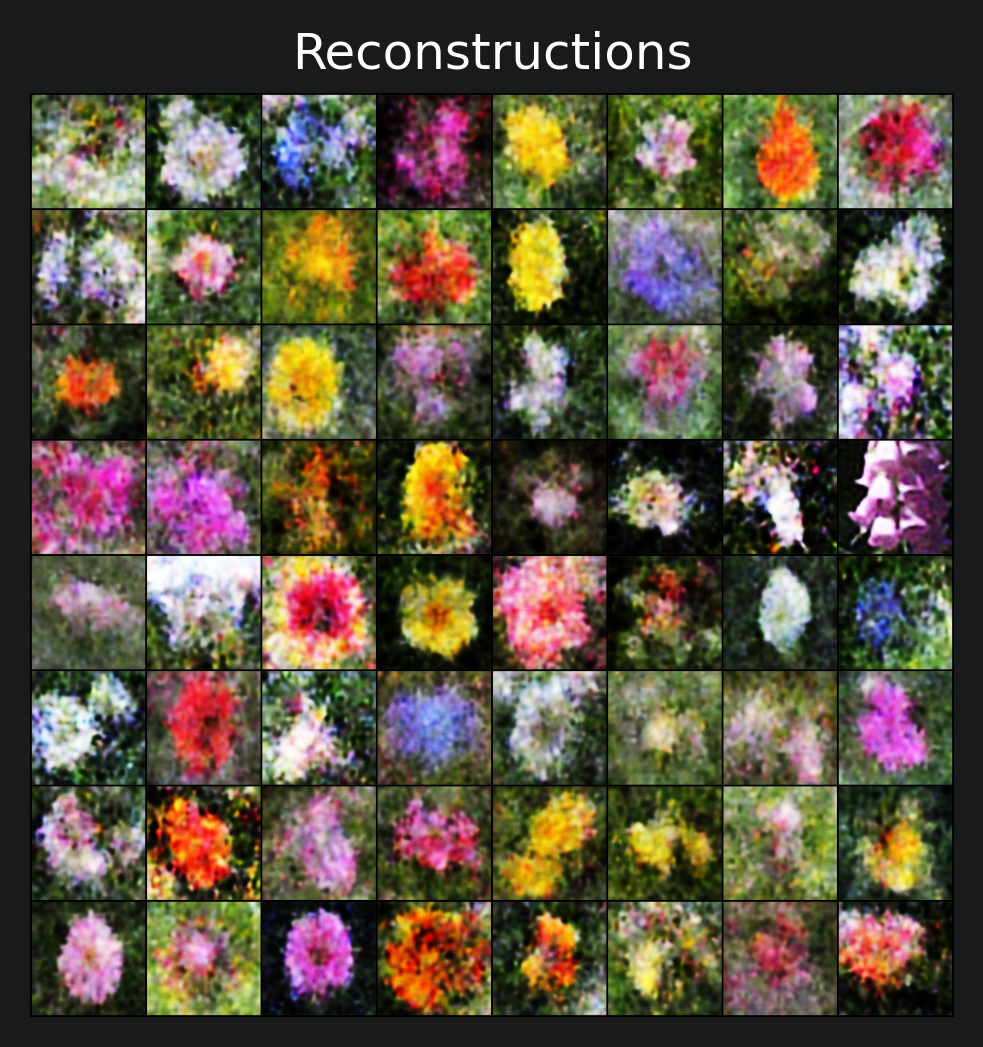

In [5]:
show(images, "Originals")
show(recon, "Reconstructions")

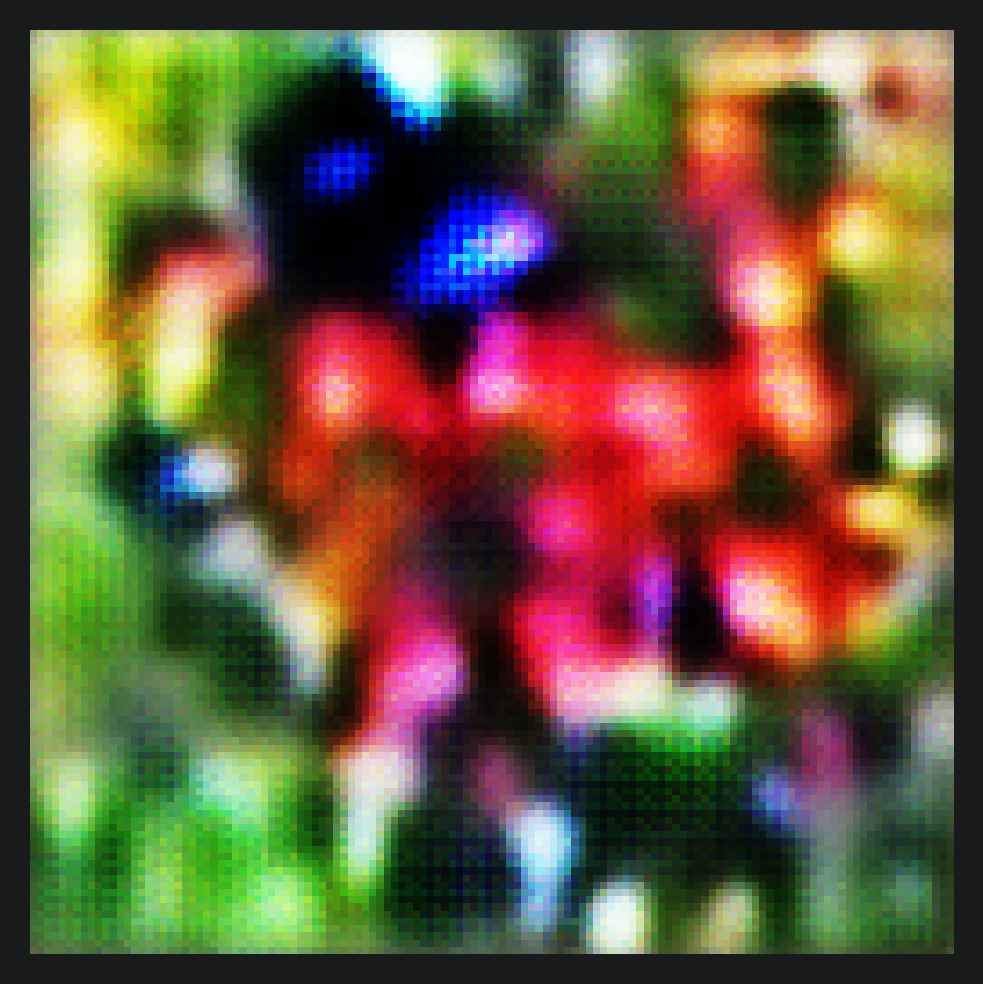

In [6]:
z_zero = torch.rand(1, ae.latent_dim)

with torch.no_grad():
    img_zero = ae.decode(z_zero)

show(img_zero)

In [9]:
latents = ae.encode(images)
print(latents.mean(dim=1))
print(latents.std(dim=1))
print(latents.min(), latents.max())

tensor([-4.7386e+01, -1.0065e+01, -7.3419e+00, -1.8576e-01,  6.1962e+00,
         1.1143e+01, -3.0958e+01, -2.8826e+01, -9.3789e+00,  1.0755e+01,
         3.9809e+00, -7.3904e-02, -6.7594e+00,  2.8919e+01,  7.9797e+00,
         4.4050e+01, -1.9855e+01, -1.3917e+01,  2.7162e+01,  4.4737e+00,
         4.7581e+01,  1.3563e+01,  8.7892e+01, -1.3850e+01, -1.8518e+01,
        -8.4357e+00,  2.1745e+01,  1.0438e+01,  3.9660e+01,  1.1453e+01,
         2.2144e+01, -4.7751e+01, -1.7802e+01,  4.4336e+01, -2.9736e+01,
        -6.7274e+00, -1.0227e+00,  2.7863e+01,  7.6699e+01,  4.6236e+01,
        -1.6707e+01, -1.1477e+01, -3.1503e+01,  4.6383e+01,  2.4141e+01,
         3.1624e+01, -1.4188e+01,  1.7912e+01, -5.2994e+01, -9.0581e+01,
         3.3816e+01, -3.9464e+01,  1.3811e+01, -8.9599e+00,  5.3385e+01,
        -4.3660e+00,  4.5053e+01, -1.3130e+01,  7.9389e+00, -3.2979e+00,
         3.1017e+01, -5.9527e+01, -5.4457e+00, -7.0174e+00],
       grad_fn=<MeanBackward1>)
tensor([308.7396, 330.6976, 334